In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
import random
from dataclasses import dataclass

In [2]:
MAX_DEPTH = 10
THRESHOLD_PREDS = 0.5
TRADING_FEES = 0.002 # trading fees = 0.2% (buy+sell)
DAYS_OF_TRADES = 30 # 30 days in a row with positive predictions
YEARS_FOR_RETURN = 4

In [3]:
df = pd.read_csv(Path('__file__').resolve().parents[3] / "resources" / "data.csv")

In [4]:
df['bullish_engulfing'] = np.where(df['Engulfing'] == -1, 1, 0)
df['bearish_engulfing'] = np.where(df['Engulfing'] == 1, 1, 0)

for feat in ['year', 'month', 'weekday']:
    df = df.join(pd.get_dummies(df[feat], prefix=feat).astype(int))
    df.drop(feat, axis=1, inplace=True)

df = df.replace([np.inf, -np.inf], np.nan)

In [5]:
columns = ['growing_moving_average',
          'Doji','Hammer','ShootingStar',
          'bullish_engulfing','bearish_engulfing',
          'year_2010','year_2011','year_2012','year_2013','year_2014','year_2015','year_2016','year_2017','year_2018',
          'year_2019','year_2020','year_2021','year_2022','year_2023','year_2024','year_2025',
          'month_1','month_2','month_3','month_4','month_5','month_6','month_7','month_8','month_9','month_10','month_11','month_12',
          'weekday_0','weekday_1','weekday_2','weekday_3','weekday_4',
           'volatility','high_minus_low_relative', 
           'ULTOSC','sharpe','Momentum','MACD_hist','CCI',
           'growth_1d','growth_90d','growth_7d','growth_30d','growth_252d','growth_3d','growth_365d',
           'RSI','ADX','+DI','-DI','MACD_signal',
           'TRIX','AvgPrice','ROC',
           'OBV','ADOSC','ATR','NATR',
           'ADXR','StochFastK','StochFastD','StochRSI_K',
           'gdppot_us_qoq','cpi_core_yoy','cpi_core_mom','fedfunds_yoy','fedfunds_mom',
           'growth_DGS1_1d','growth_DGS1_3d','growth_DGS1_7d','growth_DGS1_30d','growth_DGS1_90d','growth_DGS1_252d',
           'growth_DGS5_1d','growth_DGS5_3d','growth_DGS5_7d','growth_DGS5_30d','growth_DGS5_90d','growth_DGS5_252d','growth_DGS5_365d','spx_qoq',
           'growth_^GDAXI_1d','growth_^GDAXI_7d','growth_^GDAXI_30d','growth_^GDAXI_90d','growth_^GDAXI_252d','growth_^GDAXI_365d',
           'growth_^GSPC_1d','growth_^GSPC_7d','growth_^GSPC_30d','growth_^GSPC_90d','growth_^GSPC_365d',        
           'growth_EPI_1d','growth_EPI_3d','growth_EPI_7d','growth_EPI_30d','growth_EPI_90d','growth_EPI_252d','growth_EPI_365d',
           'growth_^VIX_1d','growth_^VIX_3d','growth_^VIX_7d','growth_^VIX_30d','growth_^VIX_90d','growth_^VIX_252d','growth_^VIX_365d',
           'growth_GC=F_1d','growth_GC=F_3d','growth_GC=F_7d','growth_GC=F_30d','growth_GC=F_90d','growth_GC=F_252d','growth_GC=F_365d',
           'growth_CL=F_1d','growth_CL=F_3d','growth_CL=F_7d','growth_CL=F_30d','growth_CL=F_90d','growth_CL=F_252d','growth_CL=F_365d',
           'growth_BZ=F_1d','growth_BZ=F_3d','growth_BZ=F_7d','growth_BZ=F_30d','growth_BZ=F_90d','growth_BZ=F_252d',
           'growth_BTC-USD_1d','growth_BTC-USD_3d','growth_BTC-USD_7d','growth_BTC-USD_30d','growth_BTC-USD_90d',
           'growth_BTC-USD_365d',
          ]

In [6]:
test_data = df[df['Date'] >= '2024-01-01']
not_test_data = df[df['Date'] < '2024-01-01']

clf = RandomForestClassifier(max_depth=MAX_DEPTH, random_state=0)
clf.fit(not_test_data[columns], not_test_data['is_positive_growth_30d_future'])
pred_proba = clf.predict_proba(df[columns])[:, 1]
pred = (pred_proba > THRESHOLD_PREDS).astype(int)

In [7]:
df['pred'] = pred
df['pred_proba'] = pred_proba
df.loc[(df['Date'] < '2024-01-01'), 'split'] = 'train'
df.loc[(df['Date'] >= '2024-01-01'), 'split'] = 'test'

In [8]:
sim1_results = []
print(f"Count times of investment {len(df[(df['split'] == 'test') & (df['pred'] == 1)])} out of {len(df[(df['split'] == 'test')])} test records")

# Fin. result columns: define new records for each positive prediction
df['sim1_gross_rev'] = (df['growth_future_30d'] - 1) * df['pred'] * 100 
df['sim1_fees'] = -df['pred'] * 100 * TRADING_FEES
df['sim1_net_rev'] = df['sim1_gross_rev'] + df['sim1_fees']

# filter records on test set, when current prediction is 1 (we invest $100 for 1 week ahead - 5 periods)
filter_test_and_positive_pred = (df['split'] == 'test') & (df['pred'] == 1)
sim1_count_investments = len(df[filter_test_and_positive_pred])
sim1_gross_rev = df[filter_test_and_positive_pred]['sim1_gross_rev'].sum()
sim1_fees = df[filter_test_and_positive_pred]['sim1_fees'].sum()
sim1_net_rev = df[filter_test_and_positive_pred]['sim1_net_rev'].sum()

if sim1_gross_rev > 0:
    sim1_fees_percentage = -sim1_fees / sim1_gross_rev
else:
    sim1_fees_percentage = None
if sim1_count_investments > 0:
    sim1_average_net_revenue = sim1_net_rev / sim1_count_investments
else:
    sim1_average_net_revenue = None

# APPROXIMATE CAPITAL REQUIRED and CAGR Calculation
df_investments_count_daily = pd.DataFrame(df[filter_test_and_positive_pred].groupby('Date')['pred'].count())
sim1_avg_investments_per_day = df_investments_count_daily['pred'].mean()
sim1_q75_investments_per_day = df_investments_count_daily['pred'].quantile(0.75)  # 75% case - how many $100 investments per day do we have?
sim1_capital = 100 * DAYS_OF_TRADES * sim1_q75_investments_per_day 

# CAGR: average growth per year. E.g. if you have 1.5 return (50% growth in 4 years) --> (1.5)**(1/4) = 1.106 or 10.6% average
sim1_CAGR = ((sim1_capital + sim1_net_rev) / sim1_capital)**(1/YEARS_FOR_RETURN)

sim1_results.append((sim1_count_investments,
                     sim1_gross_rev,
                     sim1_fees,
                     sim1_net_rev,
                     sim1_fees_percentage,
                     sim1_average_net_revenue,
                     sim1_avg_investments_per_day,
                     sim1_capital,
                     sim1_CAGR))

if sim1_count_investments > 1:  # len(filter_test_and_positive_pred)
    print(f"Financial Result: \n{df[filter_test_and_positive_pred][['sim1_gross_rev', 'sim1_fees','sim1_net_rev']].sum()}")
    print(f"Count Investments in {YEARS_FOR_RETURN} years (on test): {sim1_count_investments}")
    print(f"Gross Revenue: ${int(sim1_gross_rev)}")
    print(f"Fees ({TRADING_FEES * 100}% for buy+sell): ${int(-sim1_fees)}")
    print(f"Net Revenue: ${int(sim1_net_rev)}")
    print(f"Fees are {int(-100.0 * sim1_fees / sim1_gross_rev)}% from Gross Revenue")
    print(f"Capital Required : ${int(sim1_capital)} (Vbegin)")
    print(f"Final value (Vbegin + Net_revenue) : ${int(sim1_capital + sim1_net_rev)} (Vfinal)")

    print(f"Average CAGR on test ({YEARS_FOR_RETURN} years) : {np.round(sim1_CAGR,3)}, or {np.round(100.0 * (sim1_CAGR-1),1)}% ")

    print(f"Average daily stats: ")
    print(f"Average net revenue per investment: ${np.round(sim1_net_rev/sim1_count_investments,2)} ")
    print(f"Average investments per day: {int(np.round(sim1_avg_investments_per_day))} ")
    print(f"Q75 investments per day: {int(np.round(sim1_q75_investments_per_day))} ")

columns_simulation = ['sim1_count_investments', 'sim1_gross_rev', 'sim1_fees', 'sim1_net_rev', 
                      'sim1_fees_percentage','sim1_average_net_revenue','sim1_avg_investments_per_day','sim1_capital','sim1_CAGR']

df_sim1_results = pd.DataFrame(sim1_results, columns=columns_simulation)

Count times of investment 110310 out of 118287 test records
Financial Result: 
sim1_gross_rev    202457.607593
sim1_fees         -22062.000000
sim1_net_rev      181591.607593
dtype: float64
Count Investments in 4 years (on test): 110310
Gross Revenue: $202457
Fees (0.2% for buy+sell): $22062
Net Revenue: $181591
Fees are 10% from Gross Revenue
Capital Required : $897000 (Vbegin)
Final value (Vbegin + Net_revenue) : $1078591 (Vfinal)
Average CAGR on test (4 years) : 1.047, or 4.7% 
Average daily stats: 
Average net revenue per investment: $1.65 
Average investments per day: 279 
Q75 investments per day: 299 


In [9]:
df_sim1_results['sim1_growth_capital_4y'] = (df_sim1_results['sim1_net_rev'] + df_sim1_results['sim1_capital']) / df_sim1_results['sim1_capital']

In [10]:
df_sim1_results

,sim1_count_investments,sim1_gross_rev,sim1_fees,sim1_net_rev,sim1_fees_percentage,sim1_average_net_revenue,sim1_avg_investments_per_day,sim1_capital,sim1_CAGR,sim1_growth_capital_4y
0,110310,202457.607593,-22062.0,181591.607593,0.108971,1.646194,278.560606,897000.0,1.047167,1.202443


### Advanced simulation

In [11]:
@dataclass
class SimulationParams:
    initial_capital: float
    threshold: float
    fees: float
    top_k: int
    portfolio_optimization: bool
    stop_loss: float
    take_profit: float
    lower_entry: float

In [12]:
# future_gross_return, depending on lower_entry, take_profit, stop_loss
def get_future_gross_return(row, sim_params:SimulationParams):
  if row['lower_entry'] == 0: # no trade, investment is untouched, no fees
    return row['investment']

  # buy trade is filled for ALL next cases:
  if row['take_profit'] == 1 and row['stop_loss'] == 1:
    if random.random() > 0.5: #assume take_profit event was first
      return row['investment'] * (sim_params.take_profit + (1 - sim_params.lower_entry))
    else: #assume stop_loss event was first
      return row['investment'] * (sim_params.stop_loss + (1 - sim_params.lower_entry))

  if row['take_profit'] == 1: # take some good profit, pay fees
    return row['investment'] * (sim_params.take_profit + (1 - sim_params.lower_entry))

  if row['stop_loss'] == 1: # fix the loss, pay fees
      return row['investment'] * (sim_params.stop_loss + (1 - sim_params.lower_entry))

  # no stop_loss and no take_profit
  if pd.isna(row['growth_future_30d']):
    return row['investment'] # no information on growth in 30 days --> return the same investment in 5 days
  else:
    return row['investment'] * (row['growth_future_30d']+(1 - sim_params.lower_entry))

In [13]:
# fees, depending on lower_entry, take_profit, stop_loss
def get_fees(row, sim_params:SimulationParams):
  if row['lower_entry'] == 0: # no trade ==> no fees
    return 0

  # pay fees in all other cases
  return -row['investment'] * sim_params.fees

In [14]:
df = df.sort_values(by=['ticker', 'Date'])
df["pred_rank"] = df.groupby("Date")["pred_proba"].rank(method="first", ascending=False)

In [15]:
# get the rolling max High and min Low for the next 30 trading days

# Sort the DataFrame: Sorting by Ticker and Date ensures that we are looking at each ticker's data in chronological order.
# Rolling window calculation: We use the rolling method with a window of 30 to calculate the maximum high and minimum low over the next 30 days.

def rolling_max_min(df, window=30):
    # high/low in 30 days
    df['Max_High_Next_30'] = df['High'].rolling(window=window, min_periods=1).max().shift(-window+1)
    df['Min_Low_Next_30'] = df['Low'].rolling(window=window, min_periods=1).min().shift(-window+1)

    # low in 1 day (for lower entry)
    df['Min_Low_Next_1'] = df['Low'].rolling(window=1, min_periods=1).min().shift(-1)
    return df

In [16]:
result = df[df.split == 'test'][['Date','High','Low','Close','ticker']].groupby('ticker').apply(rolling_max_min, include_groups=False).reset_index()
result.head()

,ticker,level_1,Date,High,Low,Close,Max_High_Next_30,Min_Low_Next_30,Min_Low_Next_1
0,A,980666,2024-01-02,139.032395,136.382094,137.212784,139.032395,125.335853,129.617910
1,A,980667,2024-01-03,136.471127,129.617910,129.706909,136.471127,125.335853,128.747652
2,A,980668,2024-01-04,130.043136,128.747652,129.548676,135.393198,125.335853,127.195016
3,A,980669,2024-01-05,130.498024,127.195016,129.113525,135.393198,125.335853,128.371857
4,A,980670,2024-01-08,132.090211,128.371857,131.902313,135.393198,125.335853,128.569633


In [17]:
# Calculate the ratios + safe divide
result['Ratio_MaxHighNext30_to_Close'] = np.where(result['Close'] == 0, np.nan, result['Max_High_Next_30'] / result['Close'])
result['Ratio_MinLowNext30_to_Close'] =  np.where(result['Close'] == 0, np.nan,  result['Min_Low_Next_30'] / result['Close'])
result['Ratio_MinLowNext1_to_Close'] =  np.where(result['Close'] == 0, np.nan,  result['Min_Low_Next_1'] / result['Close'])

In [18]:
# ~2.2% cases TAKE PROFIT 30%
len(result[result.Ratio_MaxHighNext30_to_Close >= 1.3])/len(result)

0.022115701640924194

In [19]:
# ~5.4% STOP LOSS 20%
len(result[result.Ratio_MinLowNext30_to_Close <= 0.8])/len(result)

0.05228807899431045

In [20]:
df = df.merge(result[['Date', 
                      'ticker', 
                      'Max_High_Next_30', 
                      'Min_Low_Next_30',
                      'Ratio_MaxHighNext30_to_Close',
                      'Ratio_MinLowNext30_to_Close',
                      'Ratio_MinLowNext1_to_Close']], on=['Date', 'ticker'])

In [37]:
def one_date_simulation(date: str, invest_sum: float, df: pd.DataFrame, sim_params: SimulationParams):
    # 1. get TOP_K predictions from pred, that are higher than THE THRESHOLD
    if sim_params.top_k is None:
        one_day_predictions_df = df[(df['Date'] == date) & (df['pred_proba'] > sim_params.threshold)]
    else:
        one_day_predictions_df = df[(df['Date'] == date) & (df['pred_proba'] > sim_params.threshold) & (df['pred_rank'] <= sim_params.top_k)]

    FIELDS = ['Close', 'ticker', 'Date', 'pred_proba', 'pred_rank', 'growth_future_30d', 
              'Ratio_MaxHighNext30_to_Close','Ratio_MinLowNext30_to_Close','Ratio_MinLowNext1_to_Close']
    result_df = one_day_predictions_df[FIELDS].copy()

    # 2. Get non-normalized weights: probability-threshold + 0.01
    result_df['weight'] = result_df['pred_proba'] - sim_params.threshold + 0.01
    
    # 3. Get normalized weights
    result_df['weight_norm'] = result_df['weight'] / result_df['weight'].sum()
    
    # 4. Capital: either 1/30 of initial (assuming you trade every day), or everything that you can sell from 30 days ago
    result_df['investment'] = result_df['weight_norm'] * sim_params.initial_capital / DAYS_OF_TRADES

    # 5. Lower Entry: the trade is executed only is Low price for next day is lower than bet (Adj_Close_today * sim_params.lower_entry)
    # [ONLY TRADES with lower_entry==1 are filled by the exchange]
    result_df['lower_entry'] = (result_df['Ratio_MinLowNext1_to_Close'] <= sim_params.lower_entry).astype(int)
    
    # 6. Stop Loss: happens if the current price (or Low price) goes below stop loss threshold during one of the next 30 periods 
    result_df['stop_loss'] = (result_df['Ratio_MinLowNext30_to_Close'] <= sim_params.stop_loss).astype(int)
    
    # 7. Take Profit: take the money if the current Price (or Max_price) goes higher than sim_params.take_profit
    result_df['take_profit'] = (result_df['Ratio_MaxHighNext30_to_Close'] >= sim_params.take_profit).astype(int)
    
    # 8. calculate future returns (when the order is executed + stop_loss True/False + take_profit True/False)
    result_df['future_gross_return'] = result_df.apply(lambda row: get_future_gross_return(row, sim_params=sim_params), axis=1)
    result_df['fees'] = result_df.apply(lambda row: get_fees(row, sim_params=sim_params), axis=1)
    result_df['future_net_return'] = result_df['future_gross_return'] + result_df['fees']

    return result_df

In [38]:
sim_params = SimulationParams(
    initial_capital=10000,        # initial capital = $10k
    threshold=0.55,               # select all binary predictions with probability>=0.55
    fees=0.002,                   # trading fees = 0.2% (buy+sell)
    top_k=10,                     # select top_k predictions
    portfolio_optimization=False, # no portfolio optimizaiton
    stop_loss=0.8,                # automatic sell (with loss) if price (any of next 30 days) is lower than -20% from Close
    take_profit=1.3,              # automatic sell (with profit) if price (any of next 30 days) is higher than +30% from Close
    lower_entry= 0.995                # buy next day with the price = [Close] * 0.995 (try to buy cheaper)
)
r = one_date_simulation(date='2025-06-02', invest_sum=sim_params.initial_capital / DAYS_OF_TRADES, df=df, sim_params=sim_params)

In [39]:
r

,Close,ticker,Date,pred_proba,pred_rank,growth_future_30d,Ratio_MaxHighNext30_to_Close,Ratio_MinLowNext30_to_Close,Ratio_MinLowNext1_to_Close,weight,weight_norm,investment,lower_entry,stop_loss,take_profit,future_gross_return,fees,future_net_return
11046,43.821758,BAC,2025-06-02,0.616792,9.0,1.050391,1.125240,0.983666,0.996824,0.076792,0.095935,31.978170,0,0,0,31.978170,0.000000,31.978170
12630,168.384277,BDX,2025-06-02,0.616065,10.0,1.058709,1.072962,0.991381,0.991381,0.076065,0.095026,31.675221,1,0,0,33.693228,-0.063350,33.629878
22926,246.720001,COIN,2025-06-02,0.626756,1.0,1.613975,1.624838,0.953672,0.997973,0.086756,0.108381,36.127153,0,0,1,36.127153,0.000000,36.127153
25302,135.039993,CRL,2025-06-02,0.623933,3.0,1.147364,1.244964,0.981783,0.982302,0.083933,0.104855,34.951676,1,0,0,40.277046,-0.069903,40.207143
38766,41.320000,ENPH,2025-06-02,0.626343,2.0,0.944579,1.136012,0.798887,0.977493,0.086343,0.107865,35.955128,1,1,0,28.943878,-0.071910,28.871968
44310,162.000000,FI,2025-06-02,0.617900,5.0,1.022901,1.094815,0.972654,0.972654,0.077900,0.097318,32.439436,1,0,0,33.344538,-0.064879,33.279659
44706,1748.260010,FICO,2025-06-02,0.621178,4.0,0.879017,1.110018,0.844909,0.984648,0.081178,0.101413,33.804431,1,0,0,29.883686,-0.067609,29.816078
87811,132.039993,PLTR,2025-06-02,0.617321,6.0,1.142911,1.140715,0.900712,0.985308,0.077321,0.096595,32.198434,1,0,0,36.960947,-0.064397,36.896550
98841,62.424686,SWK,2025-06-02,0.617242,7.0,1.101061,1.192460,0.987490,0.988278,0.077242,0.096496,32.165478,1,0,0,35.576991,-0.064331,35.512660
115473,157.606445,WSM,2025-06-02,0.616937,8.0,1.042915,1.126090,0.961952,1.000127,0.076937,0.096115,32.038207,0,0,0,32.038207,0.000000,32.038207


In [40]:
# initial investment
r.investment.sum()

np.float64(333.33333333333337)

In [41]:
# result in 30 days (returns+fees)
r.future_net_return.sum()

np.float64(338.35746382403653)

In [51]:
def simulate(df: pd.DataFrame, sim_params: SimulationParams):
  simulation_df = None
  # all dates for simulation
  all_dates = df[df.split == 'test'].sort_values(by='Date').Date.unique()

  # arrays of dates and capital available (capital for the first 30 days)
  dates = []
  capital= DAYS_OF_TRADES * [sim_params.initial_capital / DAYS_OF_TRADES]  # first 30 periods trade with 1/30 of the initial_capital. e.g. [333,...,333] = 10k in total

  for current_date in all_dates[0:-DAYS_OF_TRADES]:  #growth_future_30d is not defined for the last 30 days : ALL, but last 30 dates
    current_invest_sum = capital[-DAYS_OF_TRADES]    # take the value or everything that you can sell from 30 days ago
    one_day_simulation_results = one_date_simulation(date = current_date,  # one day simulation result
                                    invest_sum = current_invest_sum,
                                    df = df,
                                    sim_params=sim_params,)
    # add capital available in 30 days
    if len(one_day_simulation_results) == 0:  #no predictions -> no trades
      capital.append(current_invest_sum)
    else:
      capital.append(one_day_simulation_results.future_net_return.sum())
    dates.append(current_date)

    if simulation_df is None:
      simulation_df = one_day_simulation_results
    else:
      simulation_df = pd.concat([simulation_df, one_day_simulation_results], ignore_index=True)

  # add last 30 days to make the count of data points equal for dates/capital arrays
  dates.extend(all_dates[-DAYS_OF_TRADES:])
  capital_df = pd.DataFrame({'capital':capital}, index=pd.to_datetime(dates))

  print(f'============================================================================================')
  print(f'SIMULATION STARTED')
  print(f'Simulations params: {sim_params}')
  print(f' Count bids {len(simulation_df)} in total, avg.bids per day {len(simulation_df) / simulation_df.Date.nunique()},  filled bids {len(simulation_df[simulation_df.lower_entry == 1])}, fill bids percent = {len(simulation_df[simulation_df.lower_entry == 1])/len(simulation_df)}')
  stop_loss_filter = (simulation_df['lower_entry'] == 1) & (simulation_df['stop_loss'] == 1)
  print(f'  Stop loss events: count = {len(simulation_df[stop_loss_filter])}, net loss = {simulation_df[stop_loss_filter].future_net_return.sum() - simulation_df[stop_loss_filter].investment.sum()} ')
  take_profit_filter = (simulation_df['lower_entry'] == 1) & (simulation_df['take_profit'] == 1)
  print(f'  Take profit events: count = {len(simulation_df[take_profit_filter])}, net profit = {simulation_df[take_profit_filter].future_net_return.sum()-simulation_df[take_profit_filter].investment.sum()} ')
  print(f'  Start capital = {sim_params.initial_capital}, Resulting capital: {capital_df[-DAYS_OF_TRADES:].capital.sum()} ')
  print(f'  CAGR in {YEARS_FOR_RETURN} years: {np.round((capital_df[-DAYS_OF_TRADES:].capital.sum()/sim_params.initial_capital)**(1/YEARS_FOR_RETURN),3)} or {np.round(((capital_df[-DAYS_OF_TRADES:].capital.sum()/sim_params.initial_capital)**(1/YEARS_FOR_RETURN)-1)*100.0, 2)} % of avg. growth per year')
  print(f'============================================================================================')
  return simulation_df,capital_df

In [52]:
sim_params = SimulationParams(
    initial_capital = 10000,        # initial capital = $10k
    threshold = 0.5,               # select all binary predictions with probability>=0.55
    fees = 0.002,                   # trading fees = 0.2% (buy+sell)
    top_k = 5,                      # select top_k=5 predictions
    portfolio_optimization = False, # no portfolio optimization
    stop_loss = 0.88,                # automatic sell (with loss) if price (any of next 5 days) is lower than -20% from Adj.Close
    take_profit = 1.1,              # automatic sell (with profit) if price (any of next 5 days) is higher than +30% from Adj.Close
    lower_entry = 0.99               # buy next day with the price = [Close] * 0.99 (try to buy cheaper)
)

res, capital = simulate(df, sim_params)

SIMULATION STARTED
Simulations params: SimulationParams(initial_capital=10000, threshold=0.5, fees=0.002, top_k=5, portfolio_optimization=False, stop_loss=0.88, take_profit=1.1, lower_entry=0.99)
 Count bids 1824 in total, avg.bids per day 4.983606557377049,  filled bids 841, fill bids percent = 0.4610745614035088
  Stop loss events: count = 289, net loss = -1573.1560169071454 
  Take profit events: count = 372, net profit = 1930.9734882592202 
  Start capital = 10000, Resulting capital: 10160.787213704738 
  CAGR in 4 years: 1.004 or 0.4 % of avg. growth per year


In [ ]:
# CAGR = 0.4%

In [53]:
filter_stop_loss = (res.lower_entry == 1) & (res.stop_loss == 1)
print(f'Average real close price if not stop_loss: {res[filter_stop_loss].growth_future_30d.mean()}')
res[filter_stop_loss].head(10)

Average real close price if not stop_loss: 0.9059079323574479


,Close,ticker,Date,pred_proba,pred_rank,growth_future_30d,Ratio_MaxHighNext30_to_Close,Ratio_MinLowNext30_to_Close,Ratio_MinLowNext1_to_Close,weight,weight_norm,investment,lower_entry,stop_loss,take_profit,future_gross_return,fees,future_net_return
111,305.988464,AMGN,2024-02-02,0.545561,3.0,0.844759,1.020205,0.836246,0.983044,0.055561,0.198206,66.068616,1,1,0,58.801068,-0.132137,58.668931
120,245.550003,BIIB,2024-02-06,0.546675,4.0,0.888414,1.003625,0.877011,0.979597,0.056675,0.196491,65.497087,1,1,0,58.292407,-0.130994,58.161413
241,329.269989,CRWD,2024-03-12,0.521826,2.0,0.903878,1.025845,0.853039,0.988550,0.031826,0.204354,68.118108,1,1,0,60.625116,-0.136236,60.488880
245,251.729996,COIN,2024-03-13,0.517139,5.0,0.888293,1.126127,0.817026,0.902713,0.027139,0.193335,64.444841,1,1,1,71.533774,-0.128890,71.404884
249,25.000000,PLTR,2024-03-13,0.520914,1.0,0.868400,1.019200,0.813200,0.965600,0.030914,0.220222,73.407233,1,1,0,65.332437,-0.146814,65.185623
254,45.912392,TPR,2024-03-14,0.523228,3.0,0.845829,1.020697,0.817952,0.989229,0.033228,0.200794,66.931324,1,1,0,59.568878,-0.133863,59.435016
260,321.059998,CRWD,2024-03-18,0.537511,5.0,0.911169,1.039806,0.874852,0.966237,0.047511,0.190962,63.654072,1,1,0,56.652124,-0.127308,56.524816
276,158.823334,DECK,2024-03-21,0.529595,3.0,0.883938,1.003389,0.827303,0.967060,0.039595,0.200309,66.769752,1,1,0,59.425079,-0.133540,59.291540
279,46.629925,TPR,2024-03-21,0.530217,2.0,0.815970,1.004991,0.805157,0.976295,0.040217,0.203459,67.819725,1,1,0,60.359555,-0.135639,60.223916
308,103.714996,SMCI,2024-04-01,0.548442,1.0,0.754722,1.030709,0.646965,0.940163,0.058442,0.204115,68.038339,1,1,0,60.554121,-0.136077,60.418045


In [54]:
filter_no_stop_loss_no_take_profit = (res.lower_entry == 1) & (res.take_profit == 0) & (res.stop_loss == 0)
print(f'Average real close price if no take_profit or stop loss: {res[filter_no_stop_loss_no_take_profit].growth_future_30d.mean()}')
res['realised_profit'] = res.future_net_return/res.investment
res[filter_no_stop_loss_no_take_profit][['growth_future_30d','realised_profit']].describe().T

Average real close price if no take_profit or stop loss: 0.9989919573283409


,count,mean,std,min,25%,50%,75%,max
growth_future_30d,272.0,0.998992,0.050487,0.855692,0.958213,1.002781,1.039461,1.105027
realised_profit,272.0,1.006992,0.050487,0.863692,0.966213,1.010781,1.047461,1.113027


capital    10160.787214
dtype: float64


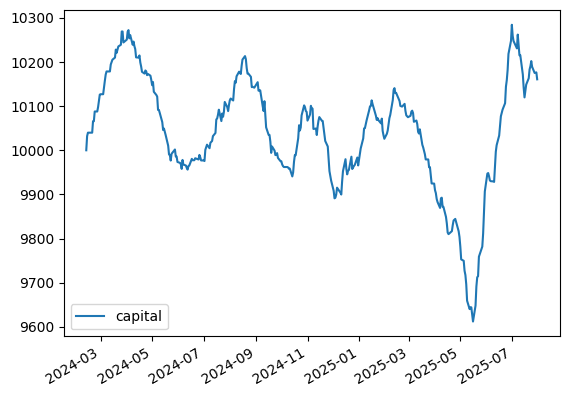

In [55]:
capital.rolling(30).sum().plot.line()
print(capital[-30:].sum())